# NER Reproduce Results

This notebook loads all four trained models from `fitted_models/` and reproduces every evaluation required by the assignment:

1. **Accuracy** on train and test sets (non-O tokens only)
2. **Confusion matrix** on train and test sets (non-O tokens only)
3. **F1-score** per class (macro and weighted)
4. **TINY TEST** predictions in `word/TAG` format with accuracy

## 0. Dependencies

In [22]:
# Install required packages — safe to re-run if already installed
!pip install sklearn-crfsuite pytorch-crf transformers accelerate seqeval -q


## 1. Imports and setup

`utils.py` contains all shared helpers: data loaders, CRF feature encoding, Structured Perceptron Viterbi decoder, evaluation functions and the TINY TEST printer. Keeping these in a separate module keeps the notebook clean and avoids code duplication between `train_models.ipynb` and this notebook.

In [23]:
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), "utils"))

import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch is needed to load the BiLSTM-CRF checkpoint and run BERT inference
import torch
import torch.nn as nn
from torchcrf import CRF

import logging

logging.getLogger("transformers").setLevel(logging.ERROR)  # suppress HF info messages
from transformers import AutoTokenizer, AutoModelForTokenClassification

# sklearn_crfsuite must be imported before unpickling the CRF model
import sklearn_crfsuite

from utils import (
    load_ner_csv,
    load_tiny_test,
 encode_crf,
    sp_token_features,
    sp_viterbi,
    evaluate_model,
    print_tiny_test,
    format_confusion_matrix,
    full_eval,
)

DATA_DIR = Path("data")
MODEL_DIR = Path("fitted_models")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Setup OK | device:", device)


Setup OK | device: cpu


## 2. Load data

All three splits are loaded here so we can evaluate every model on train, test and the tiny diagnostic set in a single run.  
The label set is derived from the union of train and test to ensure the evaluation covers all 17 BIO tags even if some are absent from one split.

In [24]:
train_sents, train_labels = load_ner_csv(DATA_DIR / "train_data_ner.csv")
test_sents, test_labels = load_ner_csv(DATA_DIR / "test_data_ner.csv")
tiny_sents, tiny_labels = load_tiny_test(DATA_DIR / "tiny_test.csv")

# Build the complete label set from both splits
all_labels = sorted({t for seq in train_labels + test_labels for t in seq})
non_O_labels = [l for l in all_labels if l != "O"]

print(f"Train : {len(train_sents)} sentences")
print(f"Test : {len(test_sents)} sentences")
print(f"Tiny : {len(tiny_sents)} sentences")
print(f"Labels ({len(all_labels)}): {all_labels}")


Train : 38366 sentences
Test : 38367 sentences
Tiny : 13 sentences
Labels (17): ['B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat', 'B-org', 'B-per', 'B-tim', 'I-art', 'I-eve', 'I-geo', 'I-gpe', 'I-nat', 'I-org', 'I-per', 'I-tim', 'O']


## 3. Model 1: CRF

The CRF is stored as a pickled `sklearn_crfsuite.CRF` object.  Loading it also restores the learned feature weights and transition matrix.  
Feature encoding (`encode_crf`) re-runs `word2features` over every sentence — this is deterministic and produces the same feature dicts as during training.

In [26]:
# Deserialise the trained CRF model (requires sklearn_crfsuite to be imported)
with open(MODEL_DIR / "crf_model" / "crf_model.pkl", "rb") as f:
    crf = pickle.load(f)
print("CRF loaded")

# Encode sentences as lists of feature dicts — same function used during training
X_train_crf, y_train_crf = encode_crf(train_sents, train_labels)
X_test_crf, y_test_crf = encode_crf(test_sents, test_labels)
X_tiny_crf, _ = encode_crf(tiny_sents, tiny_labels)

# crf.predict runs Viterbi decoding over the learned CRF parameters
y_pred_crf_train = crf.predict(X_train_crf)
y_pred_crf_test = crf.predict(X_test_crf)
y_pred_crf_tiny = crf.predict(X_tiny_crf)
print("CRF predictions done")


CRF loaded
CRF predictions done


Full evaluation for CRF on TRAIN (non-O labels only)
CRF — TRAIN  (non-O labels only)
  Accuracy  : 0.6079
  F1 macro  : 0.5208
  F1 weighted: 0.6957

              precision    recall  f1-score   support

       B-art     0.0287    0.4586    0.0541       314
       B-eve     0.6797    0.3566    0.4677       244
       B-geo     0.9530    0.5406    0.6899     30113
       B-gpe     0.9608    0.6617    0.7837     12739
       B-nat     1.0000    0.1146    0.2057       157
       B-org     0.7515    0.4577    0.5689     16127
       B-per     0.9135    0.6383    0.7515     13568
       B-tim     0.9794    0.5736    0.7235     16317
       I-art     0.0101    0.8636    0.0200       242
       I-eve     0.4024    0.4829    0.4390       205
       I-geo     0.7371    0.5190    0.6091      5898
       I-gpe     0.9846    0.3975    0.5664       161
       I-nat     1.0000    0.2045    0.3396        44
       I-org     0.6125    0.7296    0.6659     13526
       I-per     0.9198    0.7454    0

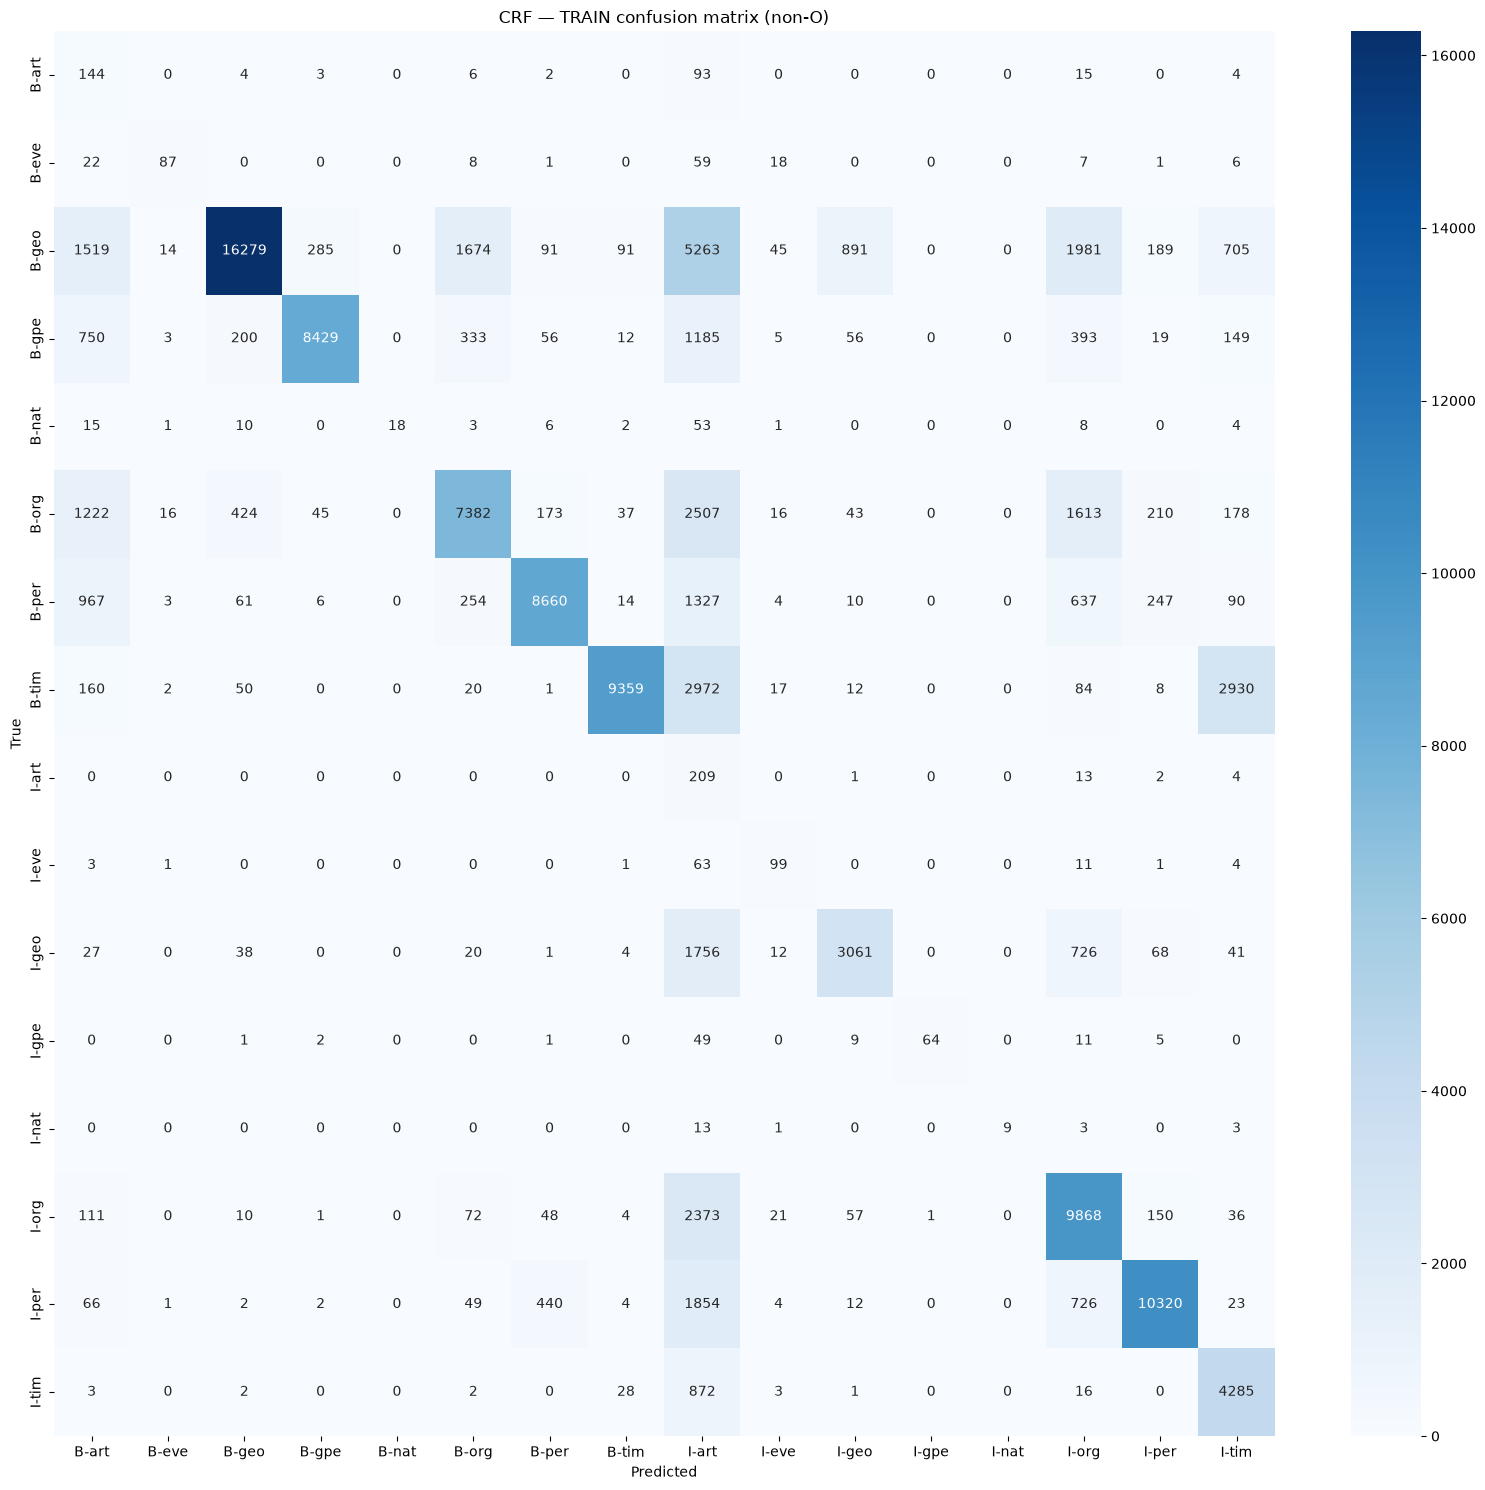

{'accuracy': 0.6079078581525031,
 'f1_macro': 0.5208177012526546,
 'f1_weighted': 0.6957401831927853,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.0287    0.4586    0.0541       314\n       B-eve     0.6797    0.3566    0.4677       244\n       B-geo     0.9530    0.5406    0.6899     30113\n       B-gpe     0.9608    0.6617    0.7837     12739\n       B-nat     1.0000    0.1146    0.2057       157\n       B-org     0.7515    0.4577    0.5689     16127\n       B-per     0.9135    0.6383    0.7515     13568\n       B-tim     0.9794    0.5736    0.7235     16317\n       I-art     0.0101    0.8636    0.0200       242\n       I-eve     0.4024    0.4829    0.4390       205\n       I-geo     0.7371    0.5190    0.6091      5898\n       I-gpe     0.9846    0.3975    0.5664       161\n       I-nat     1.0000    0.2045    0.3396        44\n       I-org     0.6125    0.7296    0.6659     13526\n       I-per     0.9198    0.7454    0.8235     13845\n    

In [27]:
# Evaluate on the training set (non-O tokens only)
# High training accuracy is expected, the CRF memorises many entity surface forms
full_eval("CRF", y_train_crf, y_pred_crf_train, "TRAIN")


Full evaluation for CRF on TEST (non-O labels only)
CRF — TEST  (non-O labels only)
  Accuracy  : 0.4152
  F1 macro  : 0.3182
  F1 weighted: 0.5106

              precision    recall  f1-score   support

       B-art     0.0114    0.2366    0.0217       317
       B-eve     0.4416    0.1399    0.2125       243
       B-geo     0.9024    0.3576    0.5122     30114
       B-gpe     0.9208    0.2998    0.4523     12649
       B-nat     1.0000    0.0057    0.0114       175
       B-org     0.5836    0.3262    0.4185     16019
       B-per     0.8338    0.4532    0.5872     13691
       B-tim     0.9606    0.3927    0.5574     16131
       I-art     0.0054    0.6471    0.0107       221
       I-eve     0.0888    0.0761    0.0820       197
       I-geo     0.5622    0.2902    0.3828      5937
       I-gpe     1.0000    0.1060    0.1916       151
       I-nat     0.0000    0.0000    0.0000        42
       I-org     0.4124    0.6228    0.4963     13281
       I-per     0.8260    0.5354    0.6

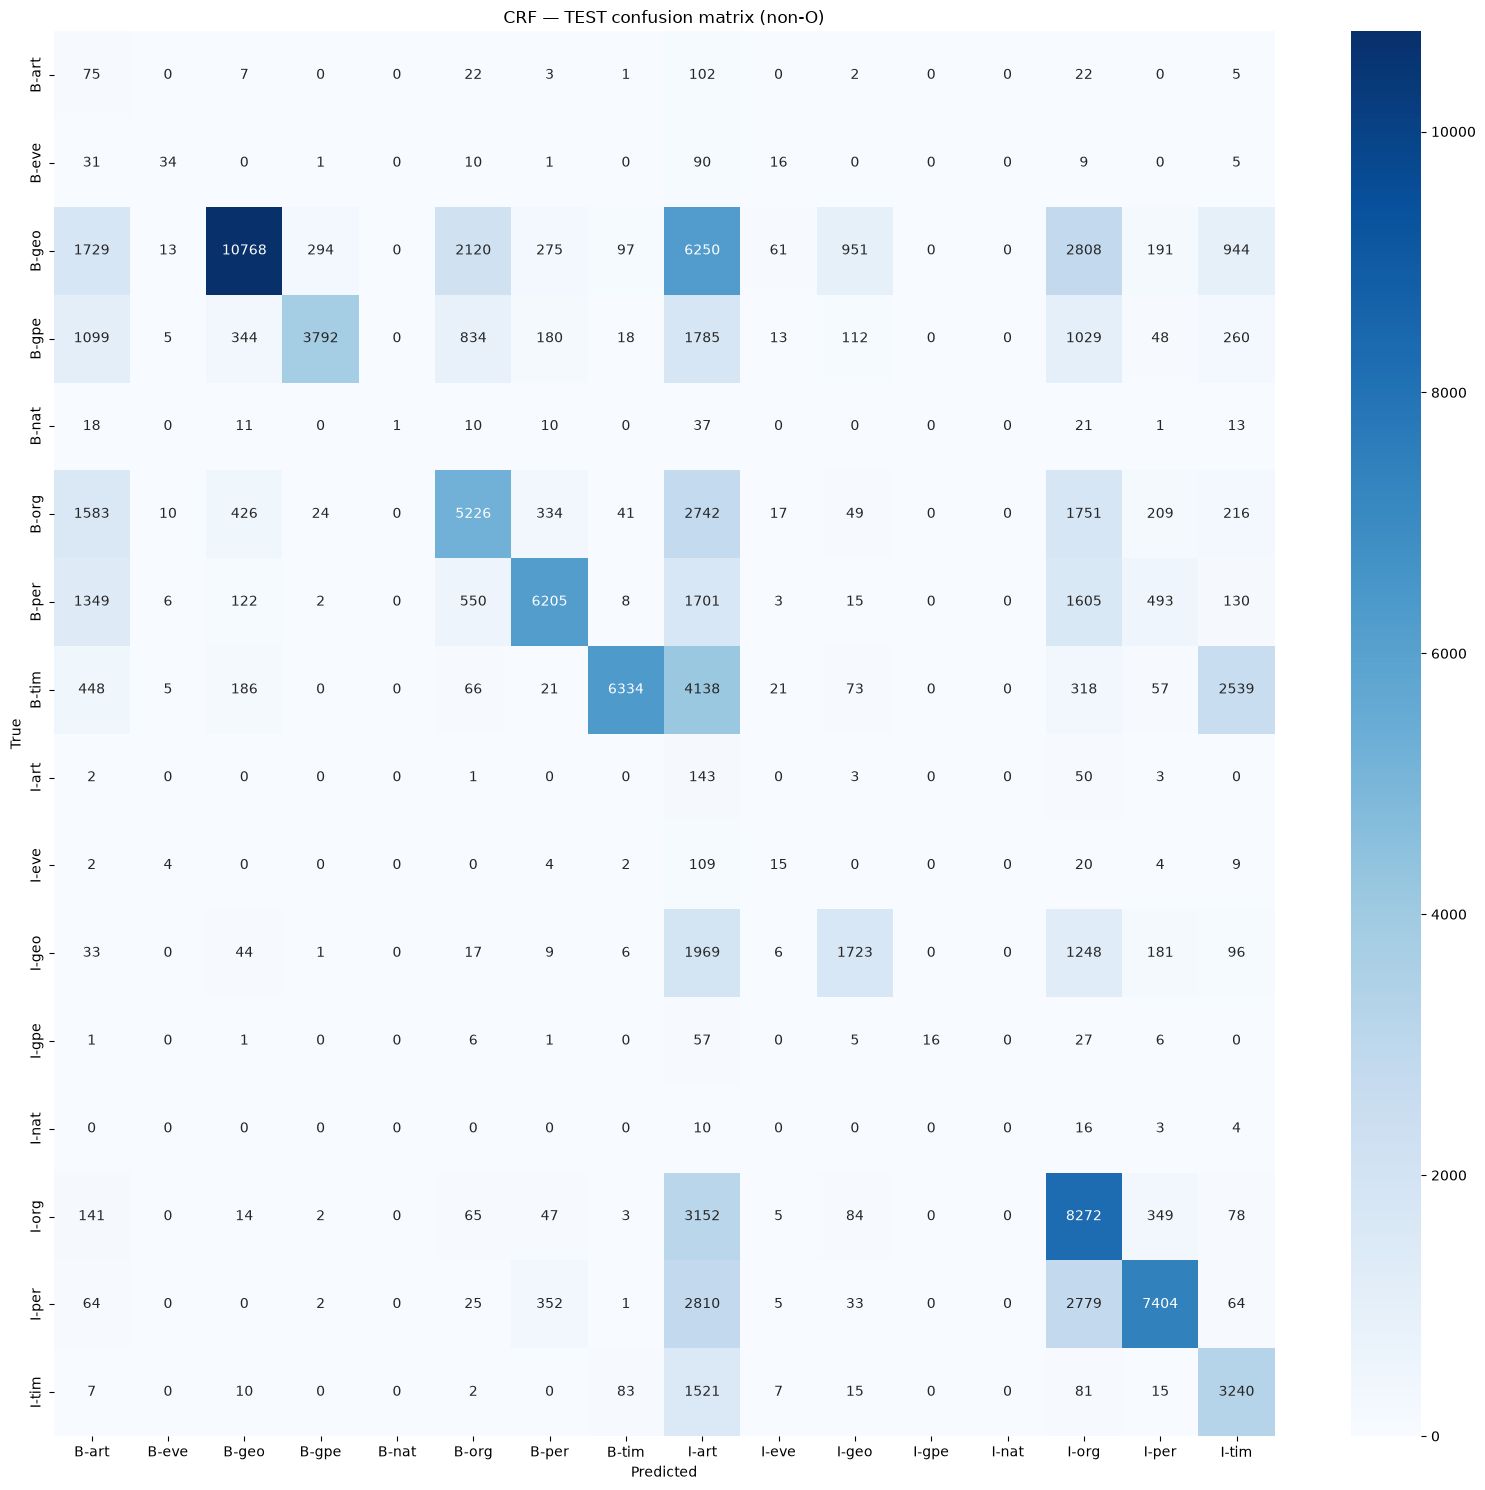

{'accuracy': 0.4152441259270235,
 'f1_macro': 0.3181894381077869,
 'f1_weighted': 0.5106360797669672,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.0114    0.2366    0.0217       317\n       B-eve     0.4416    0.1399    0.2125       243\n       B-geo     0.9024    0.3576    0.5122     30114\n       B-gpe     0.9208    0.2998    0.4523     12649\n       B-nat     1.0000    0.0057    0.0114       175\n       B-org     0.5836    0.3262    0.4185     16019\n       B-per     0.8338    0.4532    0.5872     13691\n       B-tim     0.9606    0.3927    0.5574     16131\n       I-art     0.0054    0.6471    0.0107       221\n       I-eve     0.0888    0.0761    0.0820       197\n       I-geo     0.5622    0.2902    0.3828      5937\n       I-gpe     1.0000    0.1060    0.1916       151\n       I-nat     0.0000    0.0000    0.0000        42\n       I-org     0.4124    0.6228    0.4963     13281\n       I-per     0.8260    0.5354    0.6496     13830\n    

In [28]:
# Evaluate on the test set (non-O tokens only)
# The drop vs training reflects OOV tokens and vocabulary shift between splits
full_eval("CRF", y_test_crf, y_pred_crf_test, "TEST")


## 4. Model 2: Structured Perceptron

The SP checkpoint is a dict with two keys:
- `weights`: the averaged weight vector (a `dict[str, float]`)
- `label_set`: the ordered list of tags used during training

Prediction requires running the Viterbi algorithm over the weight vector, which is slower than the CRF's `predict` because it is implemented in pure Python/numpy. Expect ~5–10 minutes for the full train set.

In [30]:
from tqdm.notebook import tqdm

# Load the averaged perceptron weight vector and its label set
with open(MODEL_DIR / "sp_model" / "sp_model.pkl", "rb") as f:
    sp_artifact = pickle.load(f)

# defaultdict(float) returns 0.0 for unseen feature keys — essential for OOV tokens
sp_weights = defaultdict(float, sp_artifact["weights"])
sp_labels = sp_artifact["label_set"]
print(f"Structured Perceptron loaded | {len(sp_weights):,} active features")

# sp_viterbi decodes the globally optimal tag sequence for each sentence
# using the Viterbi algorithm over the perceptron weight vector
y_pred_sp_train = [
    sp_viterbi(sp_weights, s, sp_labels, sp_token_features)
    for s in tqdm(train_sents, desc="SP predict train")
]
y_pred_sp_test = [
    sp_viterbi(sp_weights, s, sp_labels, sp_token_features)
    for s in tqdm(test_sents, desc="SP predict test")
]
# Tiny test is small enough to run without a progress bar
y_pred_sp_tiny = [
    sp_viterbi(sp_weights, s, sp_labels, sp_token_features) for s in tiny_sents
]
print("SP predictions done")


Structured Perceptron loaded | 7,329,499 active features


SP predict train:   0%|          | 0/38366 [00:00<?, ?it/s]

SP predict test:   0%|          | 0/38367 [00:00<?, ?it/s]

SP predictions done


Full evaluation for Structured Perceptron on TRAIN (non-O labels only)
Structured Perceptron — TRAIN  (non-O labels only)
  Accuracy  : 0.7914
  F1 macro  : 0.6352
  F1 weighted: 0.8038

              precision    recall  f1-score   support

       B-art     0.8046    0.2229    0.3491       314
       B-eve     1.0000    0.1066    0.1926       244
       B-geo     0.9521    0.6245    0.7543     30113
       B-gpe     0.8849    0.9262    0.9051     12739
       B-nat     0.9556    0.2739    0.4257       157
       B-org     0.6740    0.7727    0.7200     16127
       B-per     0.8657    0.8163    0.8403     13568
       B-tim     0.9839    0.8073    0.8869     16317
       I-art     0.9149    0.1777    0.2976       242
       I-eve     0.9500    0.1854    0.3102       205
       I-geo     0.8943    0.5780    0.7022      5898
       I-gpe     0.9439    0.6273    0.7537       161
       I-nat     0.9000    0.4091    0.5625        44
       I-org     0.7045    0.9277    0.8009     13526
  

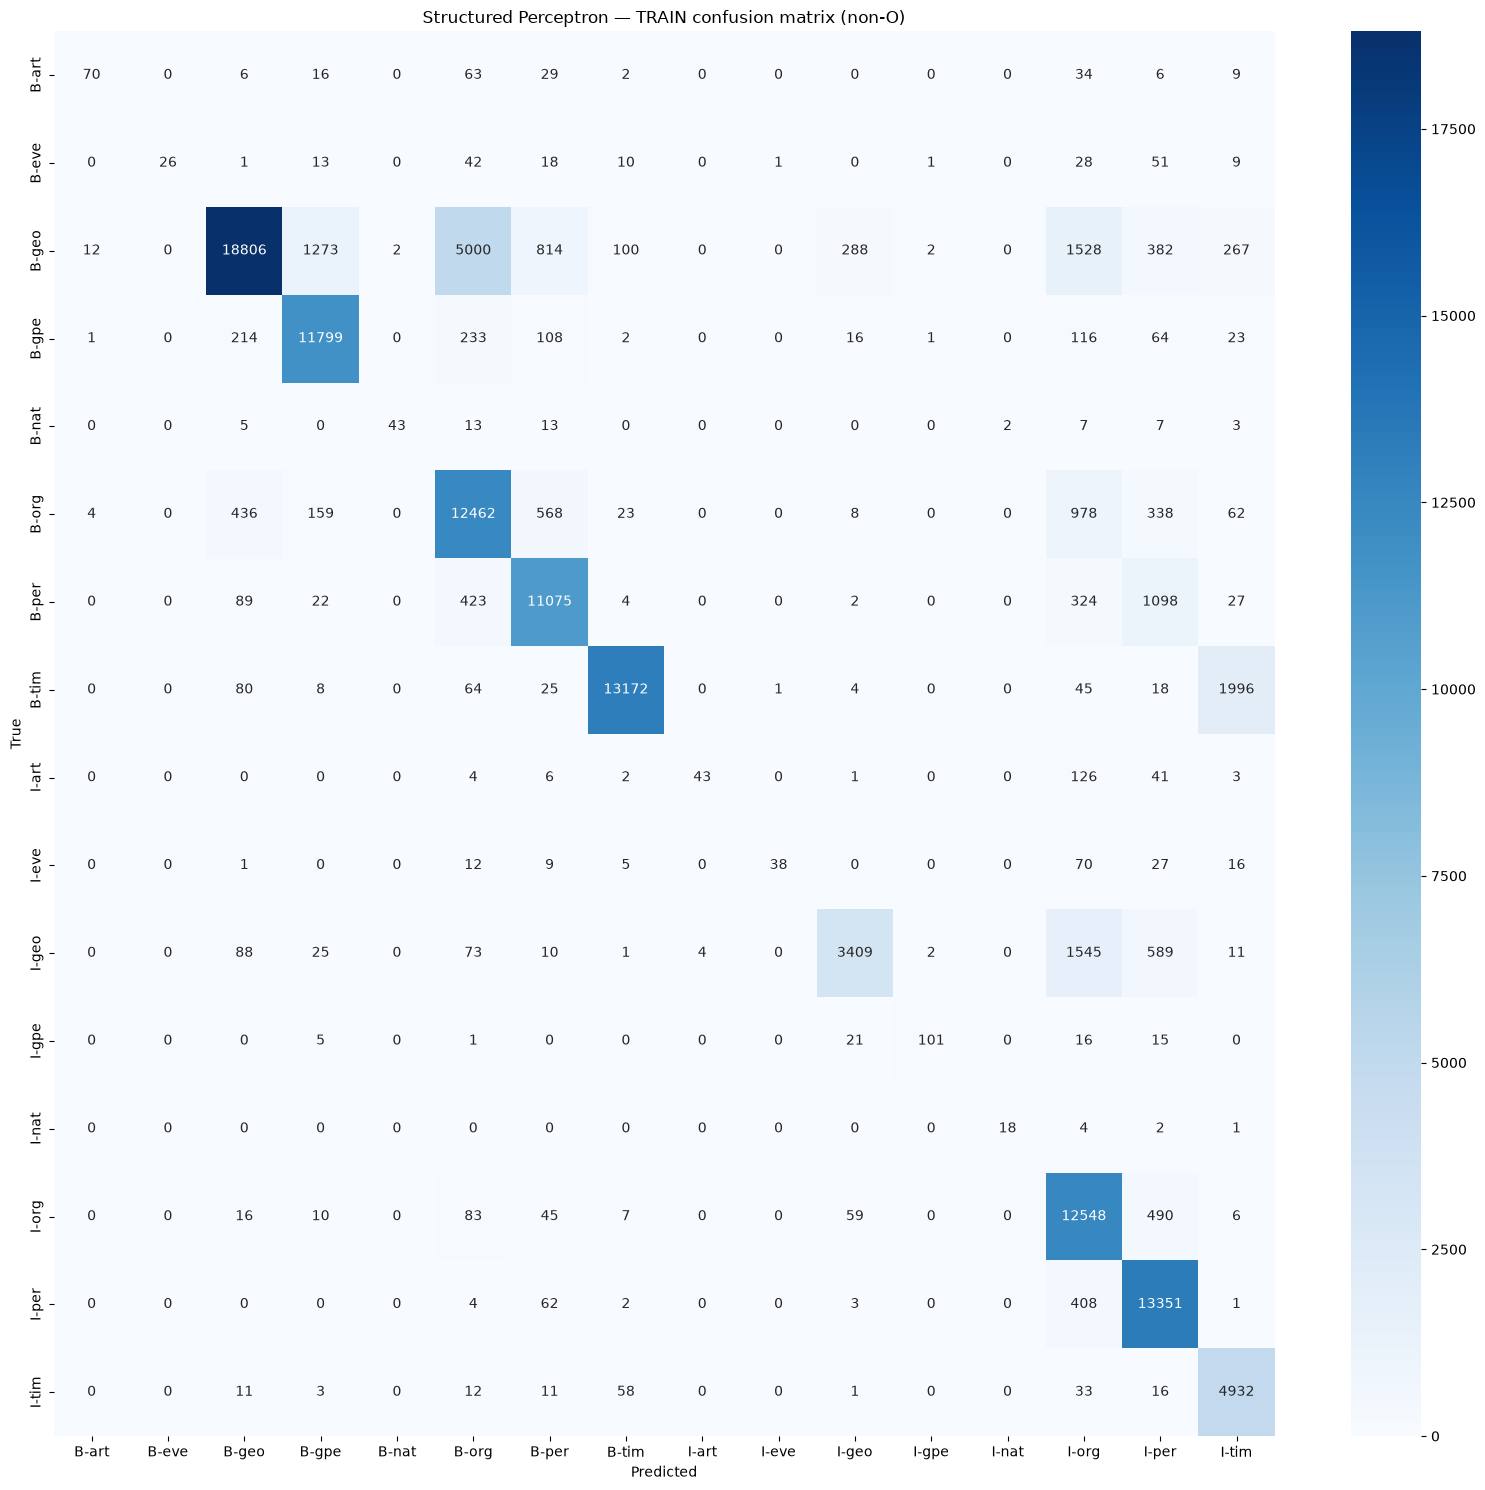

{'accuracy': 0.7913527703133009,
 'f1_macro': 0.635153886738763,
 'f1_weighted': 0.8038234170457065,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.8046    0.2229    0.3491       314\n       B-eve     1.0000    0.1066    0.1926       244\n       B-geo     0.9521    0.6245    0.7543     30113\n       B-gpe     0.8849    0.9262    0.9051     12739\n       B-nat     0.9556    0.2739    0.4257       157\n       B-org     0.6740    0.7727    0.7200     16127\n       B-per     0.8657    0.8163    0.8403     13568\n       B-tim     0.9839    0.8073    0.8869     16317\n       I-art     0.9149    0.1777    0.2976       242\n       I-eve     0.9500    0.1854    0.3102       205\n       I-geo     0.8943    0.5780    0.7022      5898\n       I-gpe     0.9439    0.6273    0.7537       161\n       I-nat     0.9000    0.4091    0.5625        44\n       I-org     0.7045    0.9277    0.8009     13526\n       I-per     0.8094    0.9643    0.8801     13845\n     

In [31]:
full_eval("Structured Perceptron", train_labels, y_pred_sp_train, "TRAIN")


Full evaluation for Structured Perceptron on TEST (non-O labels only)
Structured Perceptron — TEST  (non-O labels only)
  Accuracy  : 0.6344
  F1 macro  : 0.4179
  F1 weighted: 0.6560

              precision    recall  f1-score   support

       B-art     0.4375    0.0442    0.0802       317
       B-eve     0.8000    0.0165    0.0323       243
       B-geo     0.9249    0.4423    0.5984     30114
       B-gpe     0.7960    0.6992    0.7444     12649
       B-nat     0.9286    0.0743    0.1376       175
       B-org     0.5409    0.6440    0.5880     16019
       B-per     0.6698    0.6925    0.6810     13691
       B-tim     0.9662    0.6672    0.7893     16131
       I-art     0.3333    0.0136    0.0261       221
       I-eve     0.8000    0.0203    0.0396       197
       I-geo     0.7581    0.2644    0.3921      5937
       I-gpe     0.7407    0.2649    0.3902       151
       I-nat     1.0000    0.0476    0.0909        42
       I-org     0.5440    0.8146    0.6524     13281
    

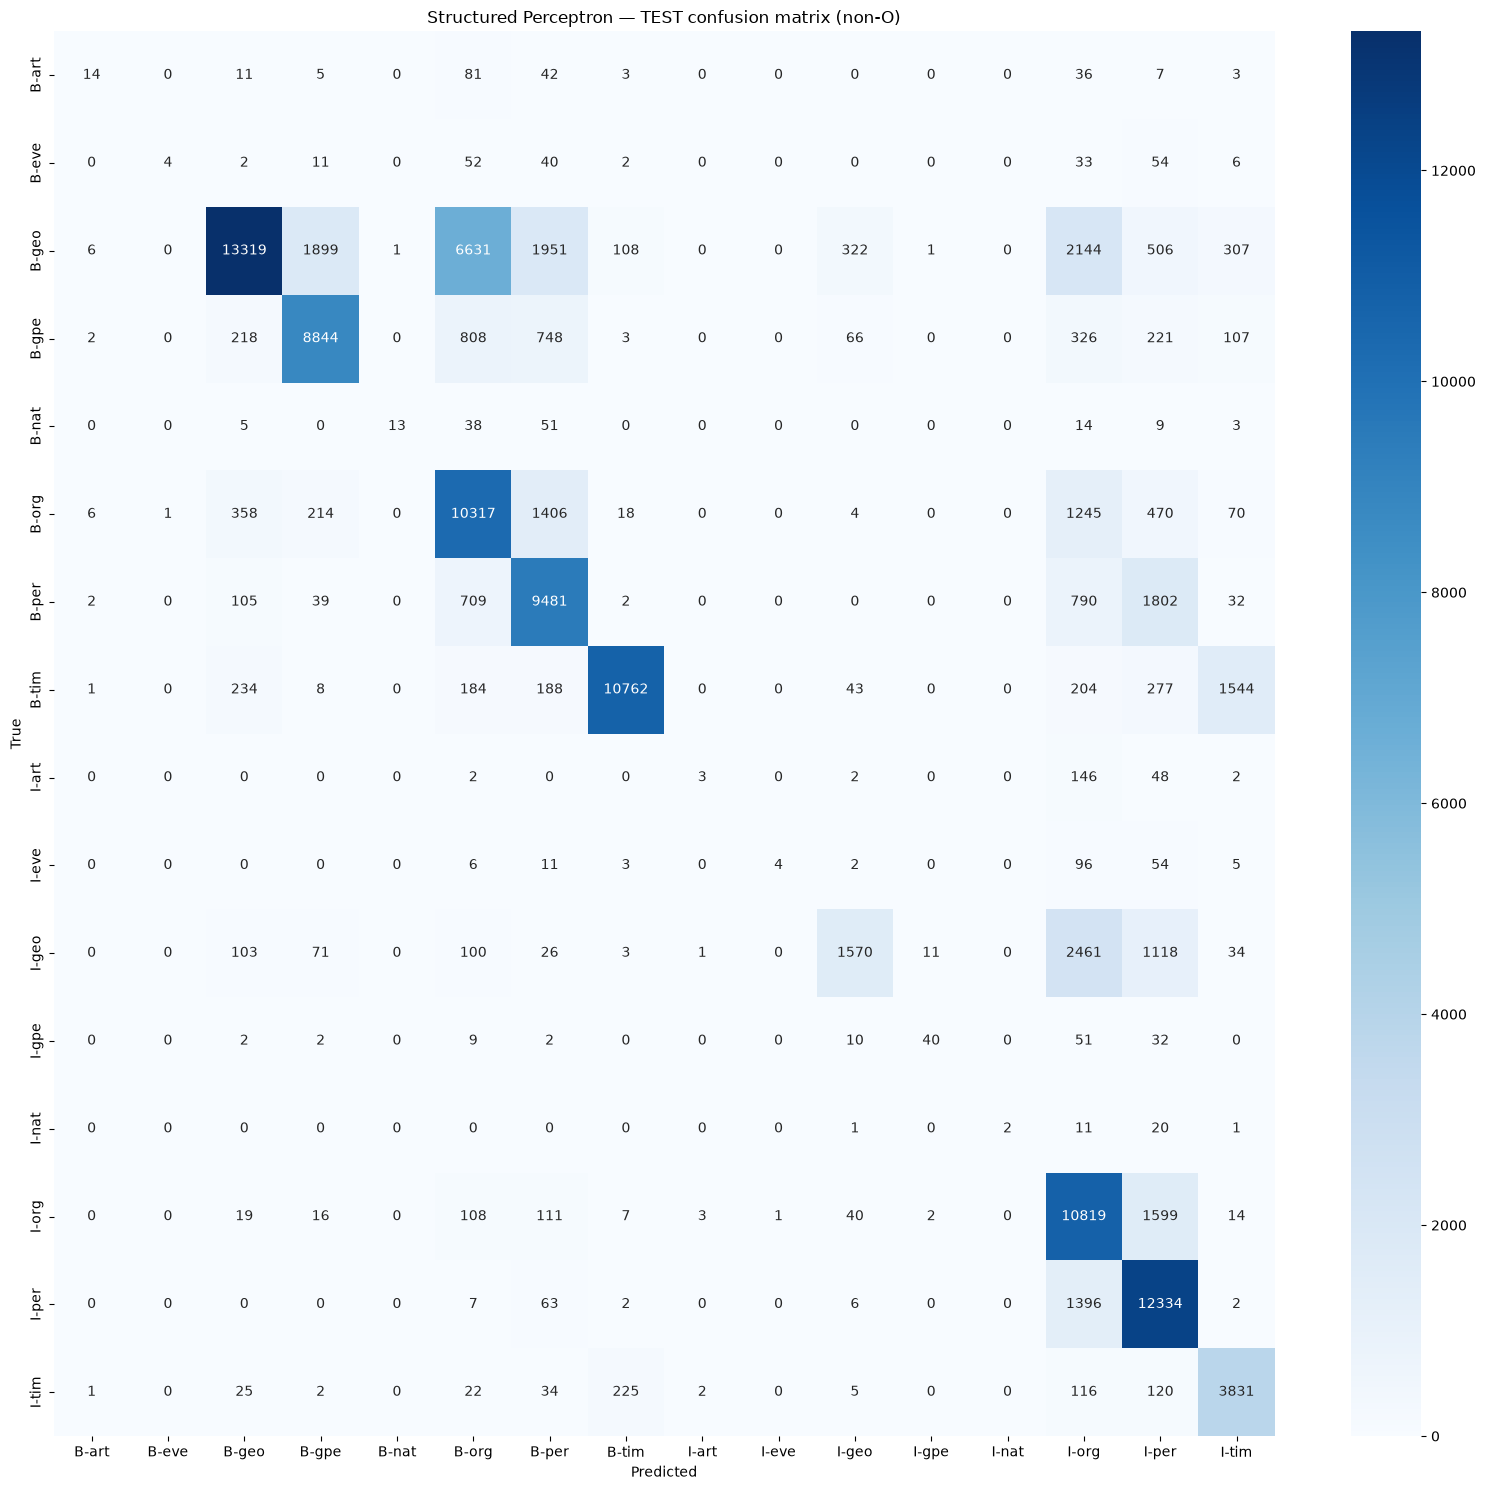

{'accuracy': 0.6344466712936607,
 'f1_macro': 0.4178650089315086,
 'f1_weighted': 0.6559667420809936,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.4375    0.0442    0.0802       317\n       B-eve     0.8000    0.0165    0.0323       243\n       B-geo     0.9249    0.4423    0.5984     30114\n       B-gpe     0.7960    0.6992    0.7444     12649\n       B-nat     0.9286    0.0743    0.1376       175\n       B-org     0.5409    0.6440    0.5880     16019\n       B-per     0.6698    0.6925    0.6810     13691\n       B-tim     0.9662    0.6672    0.7893     16131\n       I-art     0.3333    0.0136    0.0261       221\n       I-eve     0.8000    0.0203    0.0396       197\n       I-geo     0.7581    0.2644    0.3921      5937\n       I-gpe     0.7407    0.2649    0.3902       151\n       I-nat     1.0000    0.0476    0.0909        42\n       I-org     0.5440    0.8146    0.6524     13281\n       I-per     0.6606    0.8918    0.7590     13830\n    

In [32]:
full_eval("Structured Perceptron", test_labels, y_pred_sp_test, "TEST")


## 5. Model 3: BiLSTM-CRF

The checkpoint (`bilstm_crf.pt`) stores both the model weights and the vocabulary/tag mappings needed to reconstruct the exact architecture that was trained.  

The `BiLSTMCRF` class must be defined here (matching the definition in `train_models.ipynb`) before calling `load_state_dict`, because PyTorch checkpoints store weights but not the class definition itself.  

`predict_bilstm` handles variable-length sentences by padding each batch to the longest sentence and passing a boolean mask to the CRF decoder so padding positions are excluded from the Viterbi paths.

In [34]:
# BiLSTM-CRF architecture
class BiLSTMCRF(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_tags,
        num_layers=2,
        dropout=0.3,
        pad_idx=0,
    ):
        super().__init__()
        # Embedding table: vocab_size × embed_dim, padding index stays at 0
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        # 2-layer BiLSTM: hidden_dim // 2 per direction, concatenated → hidden_dim
        self.bilstm = nn.LSTM(
            embed_dim,
            hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # Linear projection: hidden_dim → num_tags (emission scores)
        self.fc = nn.Linear(hidden_dim, num_tags)
        # CRF layer: learns tag-to-tag transition scores
        self.crf = CRF(num_tags, batch_first=True)

    def _emit(self, x):
        """Forward pass through embedding + BiLSTM + linear → emission scores."""
        emb = self.dropout(self.embedding(x))
        out, _ = self.bilstm(emb)
        return self.fc(self.dropout(out))

    def forward(self, x, tags, mask):
        """Training: return CRF negative log-likelihood loss."""
        return -self.crf(self._emit(x), tags, mask=mask, reduction="mean")

    def predict(self, x, mask):
        """Inference: Viterbi decode the best tag sequence for each sentence."""
        return self.crf.decode(self._emit(x), mask=mask)


# Load checkpoint
ckpt = torch.load(MODEL_DIR / "bilstm_model" / "bilstm_crf.pt", map_location=device)
vocab = ckpt["vocab"]  # word → index mapping used during training
tag_map = ckpt["tag_map"]  # tag → index mapping
id2tag = ckpt["id2tag"]  # index → tag mapping (for converting predictions back)

# Reconstruct the model with the same hyperparameters stored in the checkpoint
bilstm_crf = BiLSTMCRF(
    vocab_size=len(vocab),
    embed_dim=ckpt["embed_dim"],
    hidden_dim=ckpt["hidden_dim"],
    num_tags=len(tag_map),
    num_layers=ckpt["num_layers"],
    dropout=ckpt["dropout"],
).to(device)
bilstm_crf.load_state_dict(ckpt["model_state"])
bilstm_crf.eval()  # disable dropout for inference
print("BiLSTM-CRF loaded")


# Batched inference helper
def predict_bilstm(model, sentences, vocab, id2tag, device, batch_size=64):
    """
    Run batched Viterbi inference on a list of sentences.
    Sentences are grouped into batches, padded to the same length within
    each batch, and decoded with the CRF Viterbi algorithm.
    """
    all_preds = []
    for start in range(0, len(sentences), batch_size):
        batch = sentences[start : start + batch_size]
        max_len = max(len(s) for s in batch)

        # Zero-padded token index tensor and boolean mask
        x_pad = torch.zeros(len(batch), max_len, dtype=torch.long)
        mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
        for i, s in enumerate(batch):
            # Unknown tokens map to <UNK> index; the model learned this during training
            ids = [vocab.get(w, vocab["<UNK>"]) for w in s]
            x_pad[i, : len(ids)] = torch.tensor(ids)
            mask[i, : len(ids)] = True

        x_pad, mask = x_pad.to(device), mask.to(device)
        with torch.no_grad():  # no gradients needed at inference time
            preds = model.predict(x_pad, mask)  # list of lists of tag indices

        for pred, sent in zip(preds, batch):
            # Convert tag indices back to string labels; truncate to true sentence length
            all_preds.append([id2tag[p] for p in pred[: len(sent)]])
    return all_preds


y_pred_bl_train = predict_bilstm(bilstm_crf, train_sents, vocab, id2tag, device)
y_pred_bl_test = predict_bilstm(bilstm_crf, test_sents, vocab, id2tag, device)
y_pred_bl_tiny = predict_bilstm(bilstm_crf, tiny_sents, vocab, id2tag, device)
print("BiLSTM-CRF predictions done")


BiLSTM-CRF loaded
BiLSTM-CRF predictions done


Full evaluation for BiLSTM-CRF on TRAIN (non-O labels only)
BiLSTM-CRF — TRAIN  (non-O labels only)
  Accuracy  : 0.9562
  F1 macro  : 0.9192
  F1 weighted: 0.9605

              precision    recall  f1-score   support

       B-art     0.9828    0.7293    0.8373       314
       B-eve     0.8972    0.7869    0.8384       244
       B-geo     0.9384    0.9769    0.9573     30113
       B-gpe     0.9893    0.9639    0.9764     12739
       B-nat     0.9333    0.7134    0.8087       157
       B-org     0.9579    0.8982    0.9271     16127
       B-per     0.9744    0.9500    0.9621     13568
       B-tim     0.9955    0.9723    0.9838     16317
       I-art     0.9905    0.8595    0.9204       242
       I-eve     0.9286    0.8244    0.8734       205
       I-geo     0.9261    0.9771    0.9509      5898
       I-gpe     0.9760    0.7578    0.8531       161
       I-nat     0.9744    0.8636    0.9157        44
       I-org     0.9785    0.9539    0.9660     13526
       I-per     0.9712 

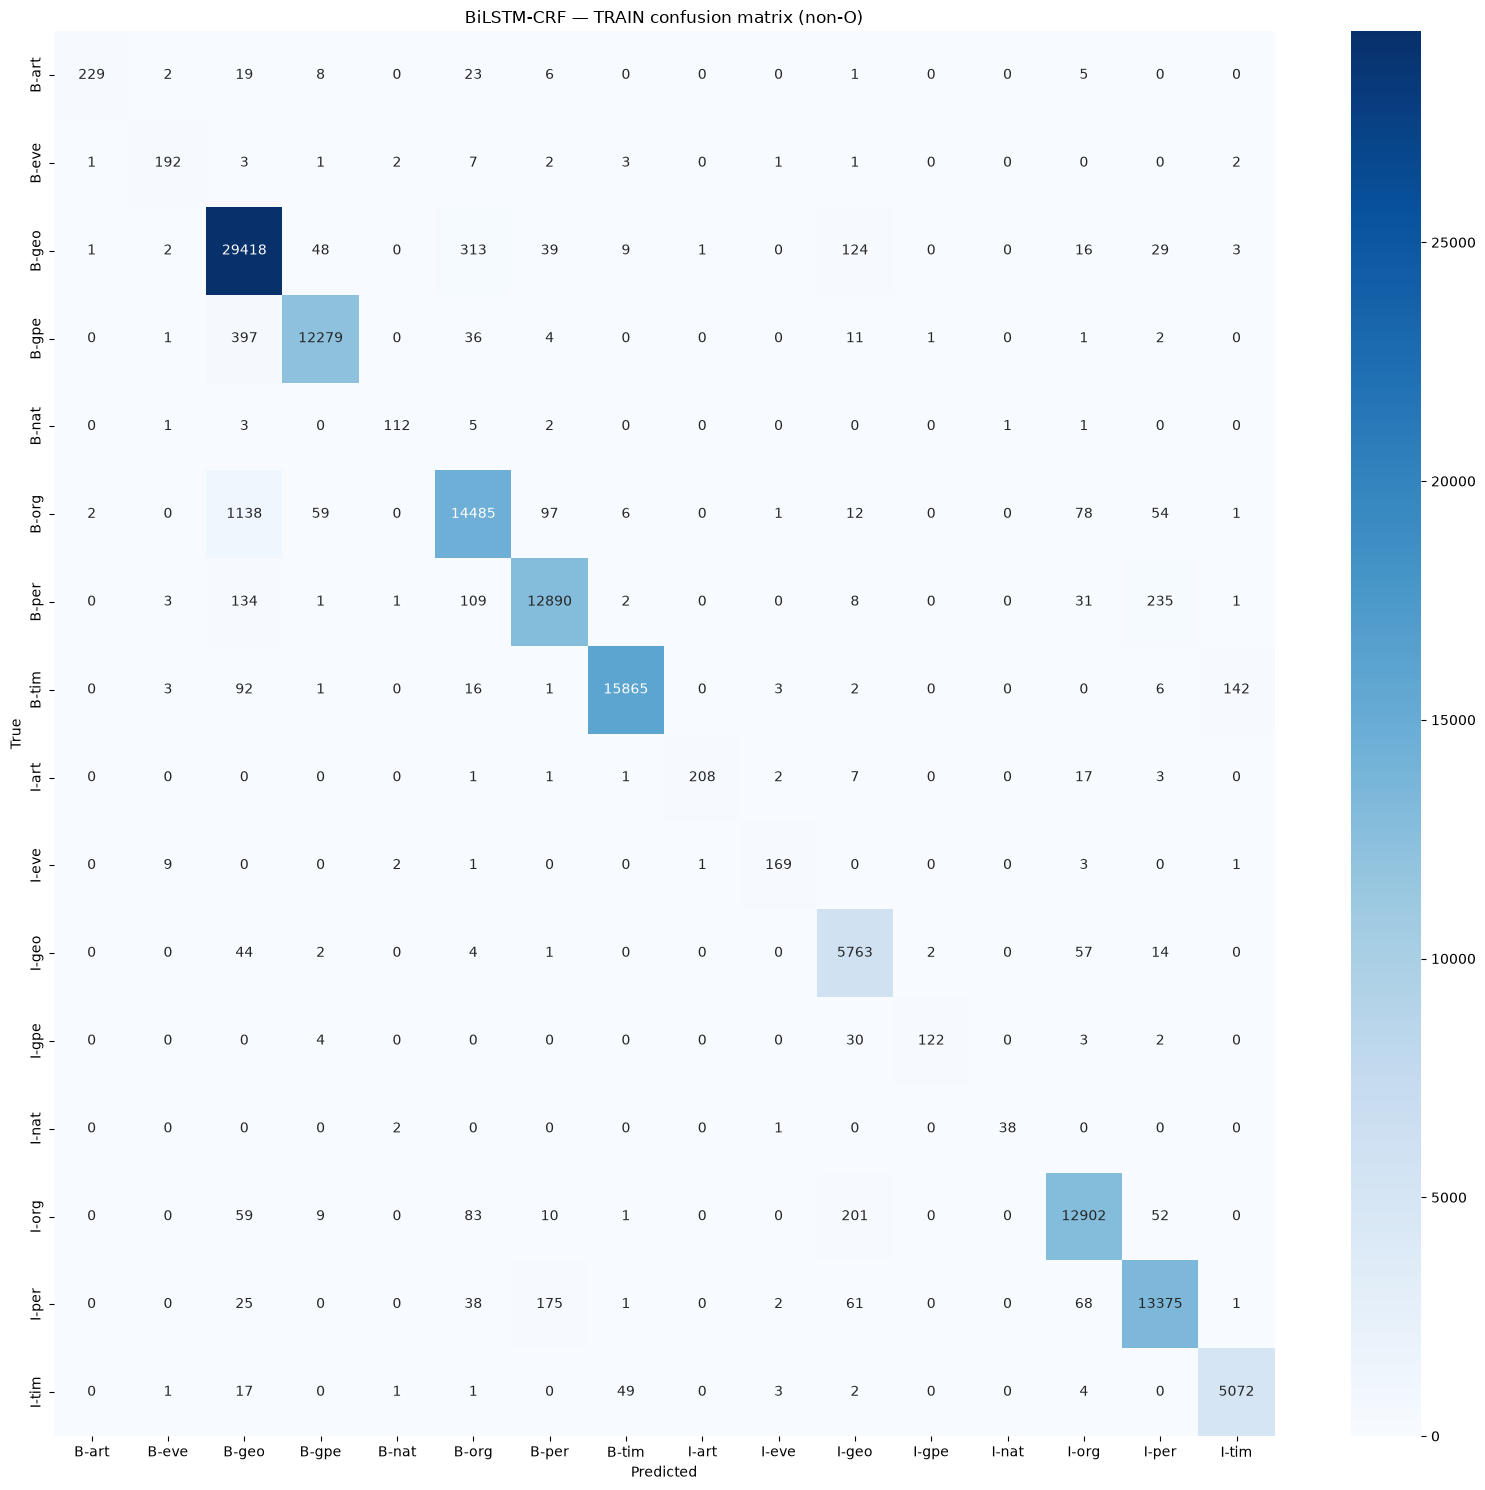

{'accuracy': 0.9562046630112304,
 'f1_macro': 0.9191819796339091,
 'f1_weighted': 0.960477963647017,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.9828    0.7293    0.8373       314\n       B-eve     0.8972    0.7869    0.8384       244\n       B-geo     0.9384    0.9769    0.9573     30113\n       B-gpe     0.9893    0.9639    0.9764     12739\n       B-nat     0.9333    0.7134    0.8087       157\n       B-org     0.9579    0.8982    0.9271     16127\n       B-per     0.9744    0.9500    0.9621     13568\n       B-tim     0.9955    0.9723    0.9838     16317\n       I-art     0.9905    0.8595    0.9204       242\n       I-eve     0.9286    0.8244    0.8734       205\n       I-geo     0.9261    0.9771    0.9509      5898\n       I-gpe     0.9760    0.7578    0.8531       161\n       I-nat     0.9744    0.8636    0.9157        44\n       I-org     0.9785    0.9539    0.9660     13526\n       I-per     0.9712    0.9661    0.9686     13845\n     

In [35]:
full_eval("BiLSTM-CRF", train_labels, y_pred_bl_train, "TRAIN")


Full evaluation for BiLSTM-CRF on TEST (non-O labels only)
BiLSTM-CRF — TEST  (non-O labels only)
  Accuracy  : 0.4884
  F1 macro  : 0.3703
  F1 weighted: 0.5386

              precision    recall  f1-score   support

       B-art     0.3600    0.0284    0.0526       317
       B-eve     0.7561    0.2551    0.3815       243
       B-geo     0.6989    0.6234    0.6590     30114
       B-gpe     0.9567    0.2374    0.3804     12649
       B-nat     0.8400    0.1200    0.2100       175
       B-org     0.7301    0.3061    0.4314     16019
       B-per     0.4572    0.6739    0.5448     13691
       B-tim     0.9361    0.3476    0.5069     16131
       I-art     0.2759    0.0362    0.0640       221
       I-eve     0.2917    0.0355    0.0633       197
       I-geo     0.5318    0.5627    0.5468      5937
       I-gpe     0.9091    0.1325    0.2312       151
       I-nat     0.8333    0.1190    0.2083        42
       I-org     0.7588    0.3244    0.4545     13281
       I-per     0.6199   

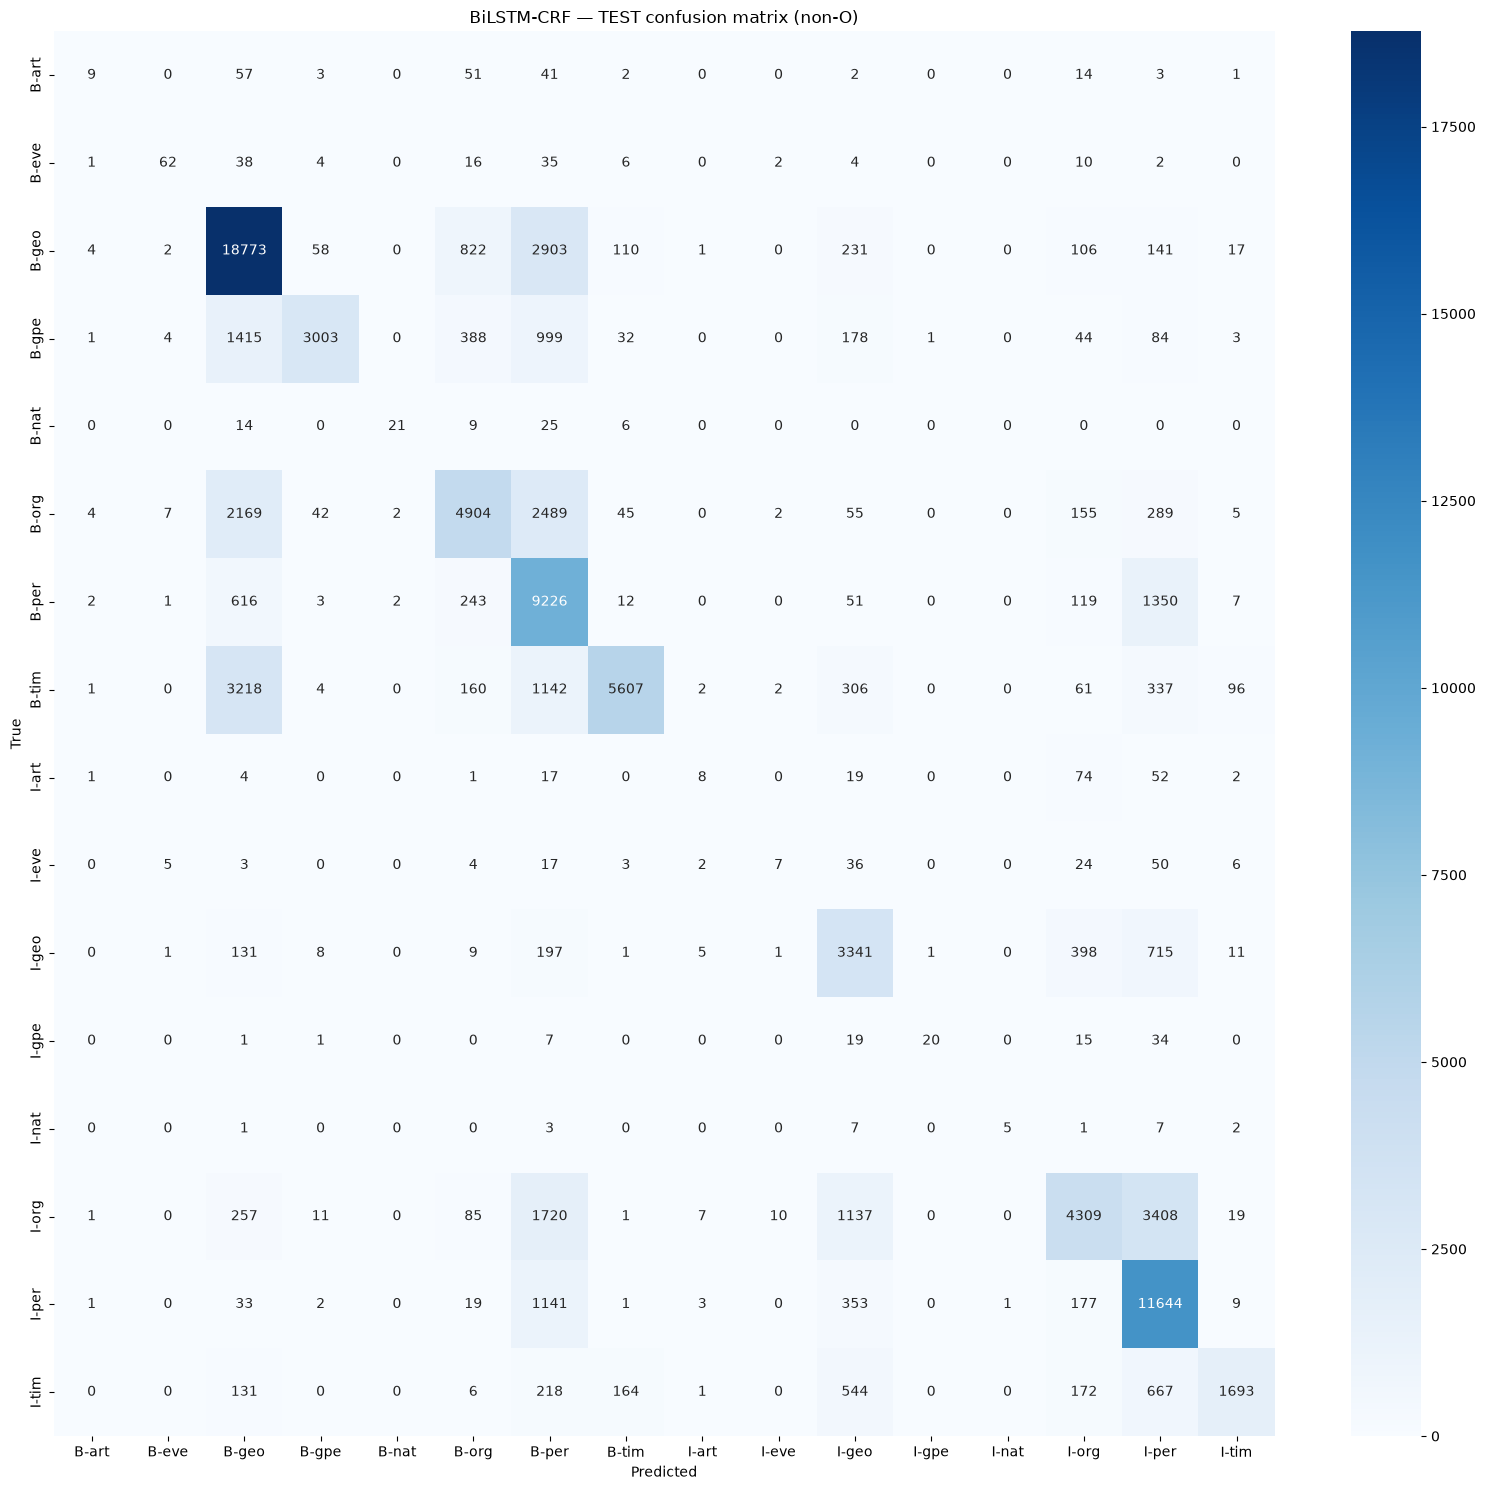

{'accuracy': 0.4884234167491987,
 'f1_macro': 0.3703427755395975,
 'f1_weighted': 0.5386493592322588,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.3600    0.0284    0.0526       317\n       B-eve     0.7561    0.2551    0.3815       243\n       B-geo     0.6989    0.6234    0.6590     30114\n       B-gpe     0.9567    0.2374    0.3804     12649\n       B-nat     0.8400    0.1200    0.2100       175\n       B-org     0.7301    0.3061    0.4314     16019\n       B-per     0.4572    0.6739    0.5448     13691\n       B-tim     0.9361    0.3476    0.5069     16131\n       I-art     0.2759    0.0362    0.0640       221\n       I-eve     0.2917    0.0355    0.0633       197\n       I-geo     0.5318    0.5627    0.5468      5937\n       I-gpe     0.9091    0.1325    0.2312       151\n       I-nat     0.8333    0.1190    0.2083        42\n       I-org     0.7588    0.3244    0.4545     13281\n       I-per     0.6199    0.8419    0.7141     13830\n    

In [36]:
full_eval("BiLSTM-CRF", test_labels, y_pred_bl_test, "TEST")


## 6. Model 4: BERT-base-cased

`bert_ner/` is a Hugging Face model directory containing the fine-tuned weights, tokeniser vocabulary and `config.json` (which stores the `id2label` mapping).  

`predict_bert` handles the sub-word alignment: BERT tokenises each word into one or more sub-word pieces, but we only need the prediction for the **first piece** of each word. All other positions (continuation pieces, padding, `[CLS]`, `[SEP]`) are skipped using `word_ids()` which maps each token position back to its original word index.

In [38]:
# Load the fine-tuned BERT model and its tokeniser from the saved directory
bert_model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR / "bert_ner_model")
bert_tok = AutoTokenizer.from_pretrained(MODEL_DIR / "bert_ner_model")
bert_model.eval().to(device)  # set to eval mode: disables dropout in transformer layers

# id2label is stored in config.json; keys are strings in HF checkpoints → cast to int
id2tag_bert = {int(k): v for k, v in bert_model.config.id2label.items()}
print(f"BERT loaded | {len(id2tag_bert)} labels: {list(id2tag_bert.values())[:5]} …")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERT loaded | 17 labels: ['B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat'] …


In [39]:
def predict_bert(model, tokenizer, sentences, id2tag, device, batch_size=32):
    """
    Run batched BERT inference with sub-word to word alignment.

    For each sentence:
    1. Tokenise with is_split_into_words=True (words already split by us)
    2. Run forward pass → logits shape (batch, seq_len, num_labels)
    3. Take argmax over labels at each position
    4. Keep only the prediction for the first sub-word token of each word
       (identified via word_ids() which returns None for special tokens and
       the original word index for sub-word tokens)
    """
    all_preds = []
    for start in range(0, len(sentences), batch_size):
        batch = sentences[start : start + batch_size]

        # Tokenise: padding + truncation to max_length=128
        enc = tokenizer(
            batch,
            is_split_into_words=True,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            logits = model(**enc).logits  # (batch, seq_len, num_labels)

        # Convert logits to predicted label indices
        preds = logits.argmax(-1).cpu().tolist()

        for i, sent in enumerate(batch):
            word_ids = enc.word_ids(batch_index=i)
            sent_pred = []
            prev_wid = None
            for wid, pred in zip(word_ids, preds[i]):
                if wid is None:  # special token ([CLS], [SEP], padding)
                    prev_wid = wid
                    continue
                if wid == prev_wid:  # continuation sub-word piece — skip
                    continue
                # First sub-word of a new word → record its prediction
                sent_pred.append(id2tag[pred])
                prev_wid = wid

            # Truncate to original sentence length (handles edge cases)
            all_preds.append(sent_pred[: len(sent)])
    return all_preds


y_pred_bert_train = predict_bert(bert_model, bert_tok, train_sents, id2tag_bert, device)
y_pred_bert_test = predict_bert(bert_model, bert_tok, test_sents, id2tag_bert, device)
y_pred_bert_tiny = predict_bert(bert_model, bert_tok, tiny_sents, id2tag_bert, device)
print("BERT predictions done")


BERT predictions done


Full evaluation for BERT-base-cased on TRAIN (non-O labels only)
BERT-base-cased — TRAIN  (non-O labels only)
  Accuracy  : 0.9515
  F1 macro  : 0.8828
  F1 weighted: 0.9563

              precision    recall  f1-score   support

       B-art     0.8819    0.8089    0.8439       314
       B-eve     0.8528    0.8074    0.8295       244
       B-geo     0.9344    0.9745    0.9540     30112
       B-gpe     0.9849    0.9651    0.9749     12739
       B-nat     0.8376    0.6242    0.7153       157
       B-org     0.9603    0.8783    0.9174     16124
       B-per     0.9665    0.9393    0.9527     13568
       B-tim     0.9943    0.9750    0.9845     16317
       I-art     0.8450    0.9008    0.8720       242
       I-eve     0.8359    0.7951    0.8150       205
       I-geo     0.9413    0.9618    0.9514      5897
       I-gpe     0.9646    0.6770    0.7956       161
       I-nat     0.8750    0.4773    0.6176        44
       I-org     0.9722    0.9627    0.9675     13523
       I-per  

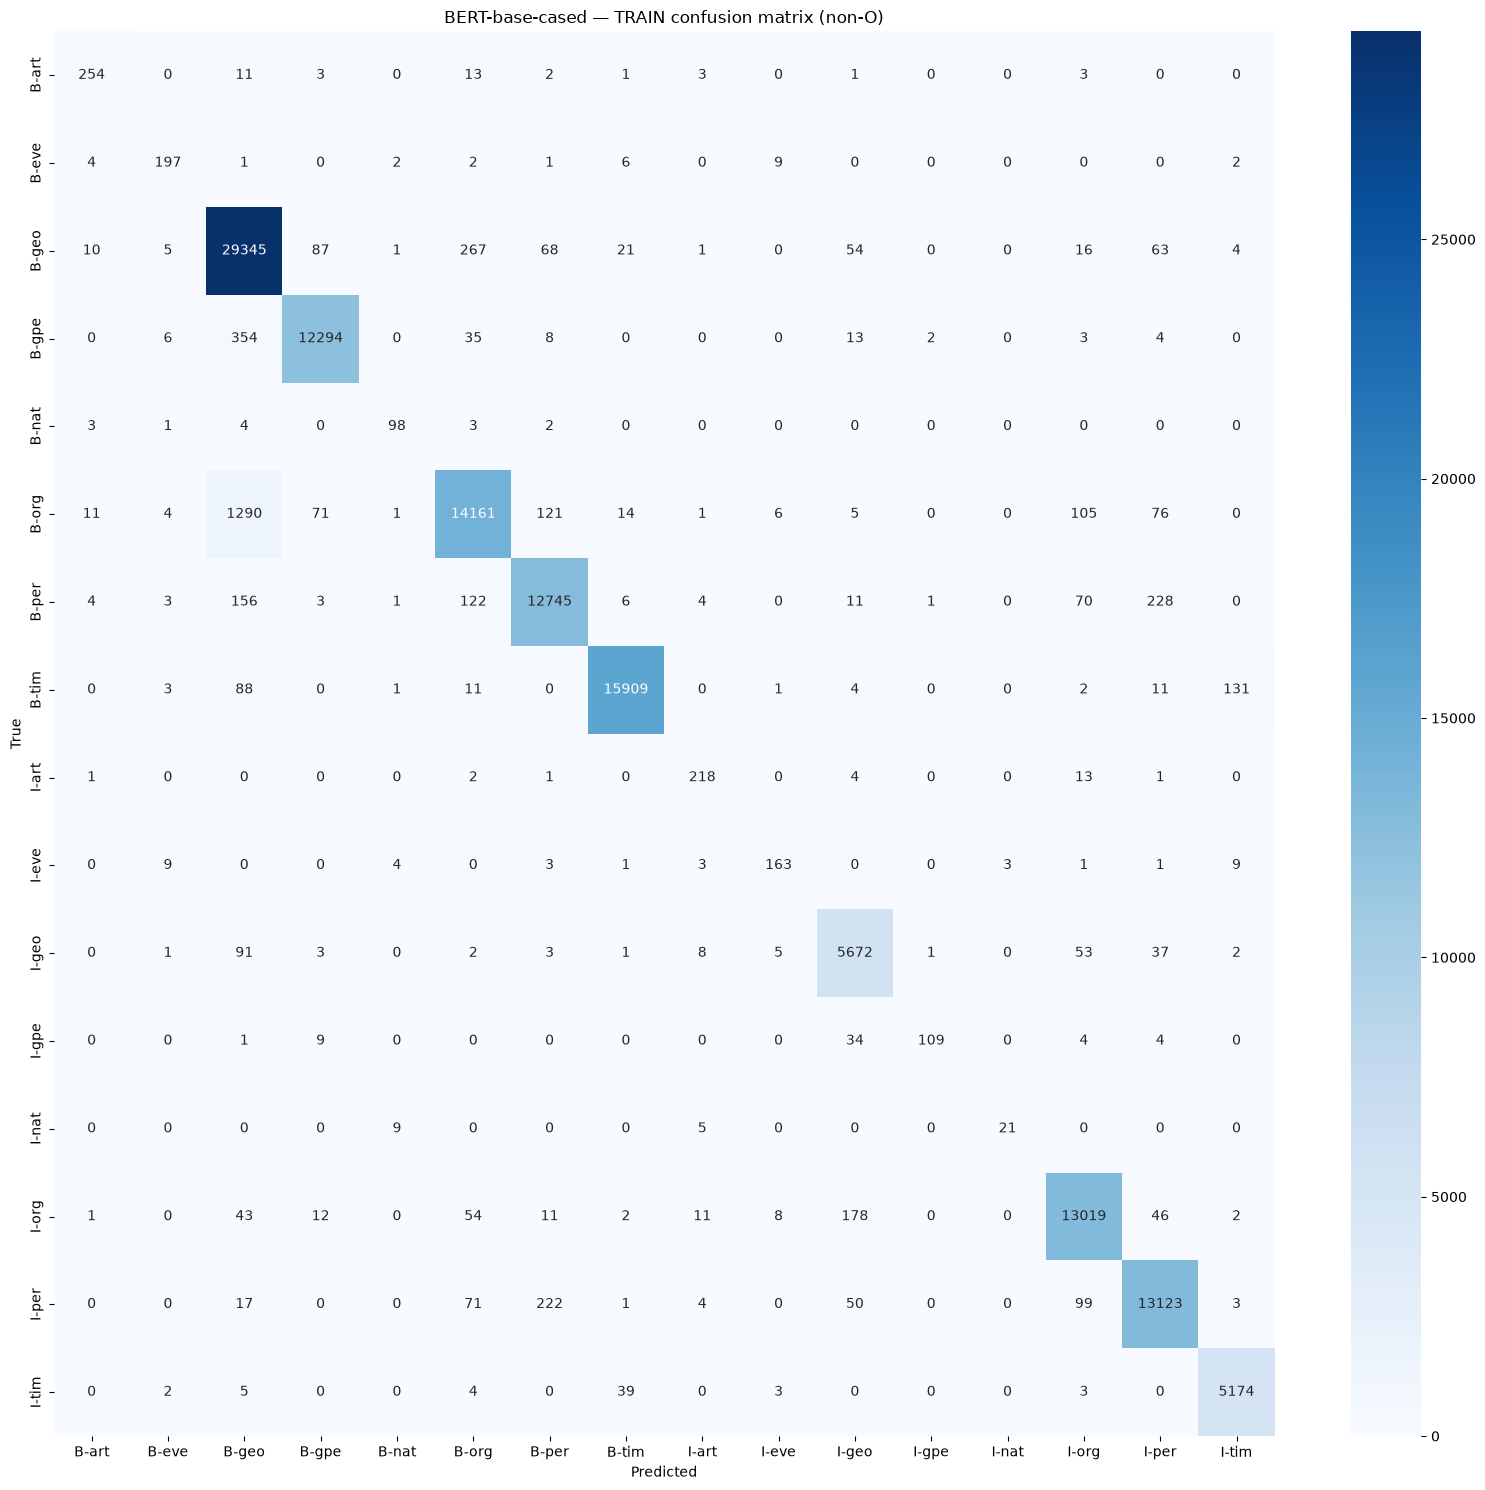

{'accuracy': 0.9514718446601942,
 'f1_macro': 0.8828472098394597,
 'f1_weighted': 0.9562761612524314,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.8819    0.8089    0.8439       314\n       B-eve     0.8528    0.8074    0.8295       244\n       B-geo     0.9344    0.9745    0.9540     30112\n       B-gpe     0.9849    0.9651    0.9749     12739\n       B-nat     0.8376    0.6242    0.7153       157\n       B-org     0.9603    0.8783    0.9174     16124\n       B-per     0.9665    0.9393    0.9527     13568\n       B-tim     0.9943    0.9750    0.9845     16317\n       I-art     0.8450    0.9008    0.8720       242\n       I-eve     0.8359    0.7951    0.8150       205\n       I-geo     0.9413    0.9618    0.9514      5897\n       I-gpe     0.9646    0.6770    0.7956       161\n       I-nat     0.8750    0.4773    0.6176        44\n       I-org     0.9722    0.9627    0.9675     13523\n       I-per     0.9654    0.9479    0.9565     13845\n    

In [40]:
full_eval("BERT-base-cased", train_labels, y_pred_bert_train, "TRAIN")


Full evaluation for BERT-base-cased on TEST (non-O labels only)
BERT-base-cased — TEST  (non-O labels only)
  Accuracy  : 0.6678
  F1 macro  : 0.5281
  F1 weighted: 0.6945

              precision    recall  f1-score   support

       B-art     0.2804    0.2397    0.2585       317
       B-eve     0.5026    0.3992    0.4450       243
       B-geo     0.7671    0.7762    0.7717     30113
       B-gpe     0.9420    0.3788    0.5404     12649
       B-nat     0.8400    0.2400    0.3733       175
       B-org     0.5850    0.6919    0.6340     16016
       B-per     0.6800    0.6983    0.6890     13691
       B-tim     0.9566    0.6331    0.7620     16131
       I-art     0.1748    0.3258    0.2275       221
       I-eve     0.3873    0.2792    0.3245       197
       I-geo     0.6905    0.5337    0.6021      5936
       I-gpe     0.8929    0.1656    0.2793       151
       I-nat     1.0000    0.2381    0.3846        42
       I-org     0.5674    0.8001    0.6640     13278
       I-per    

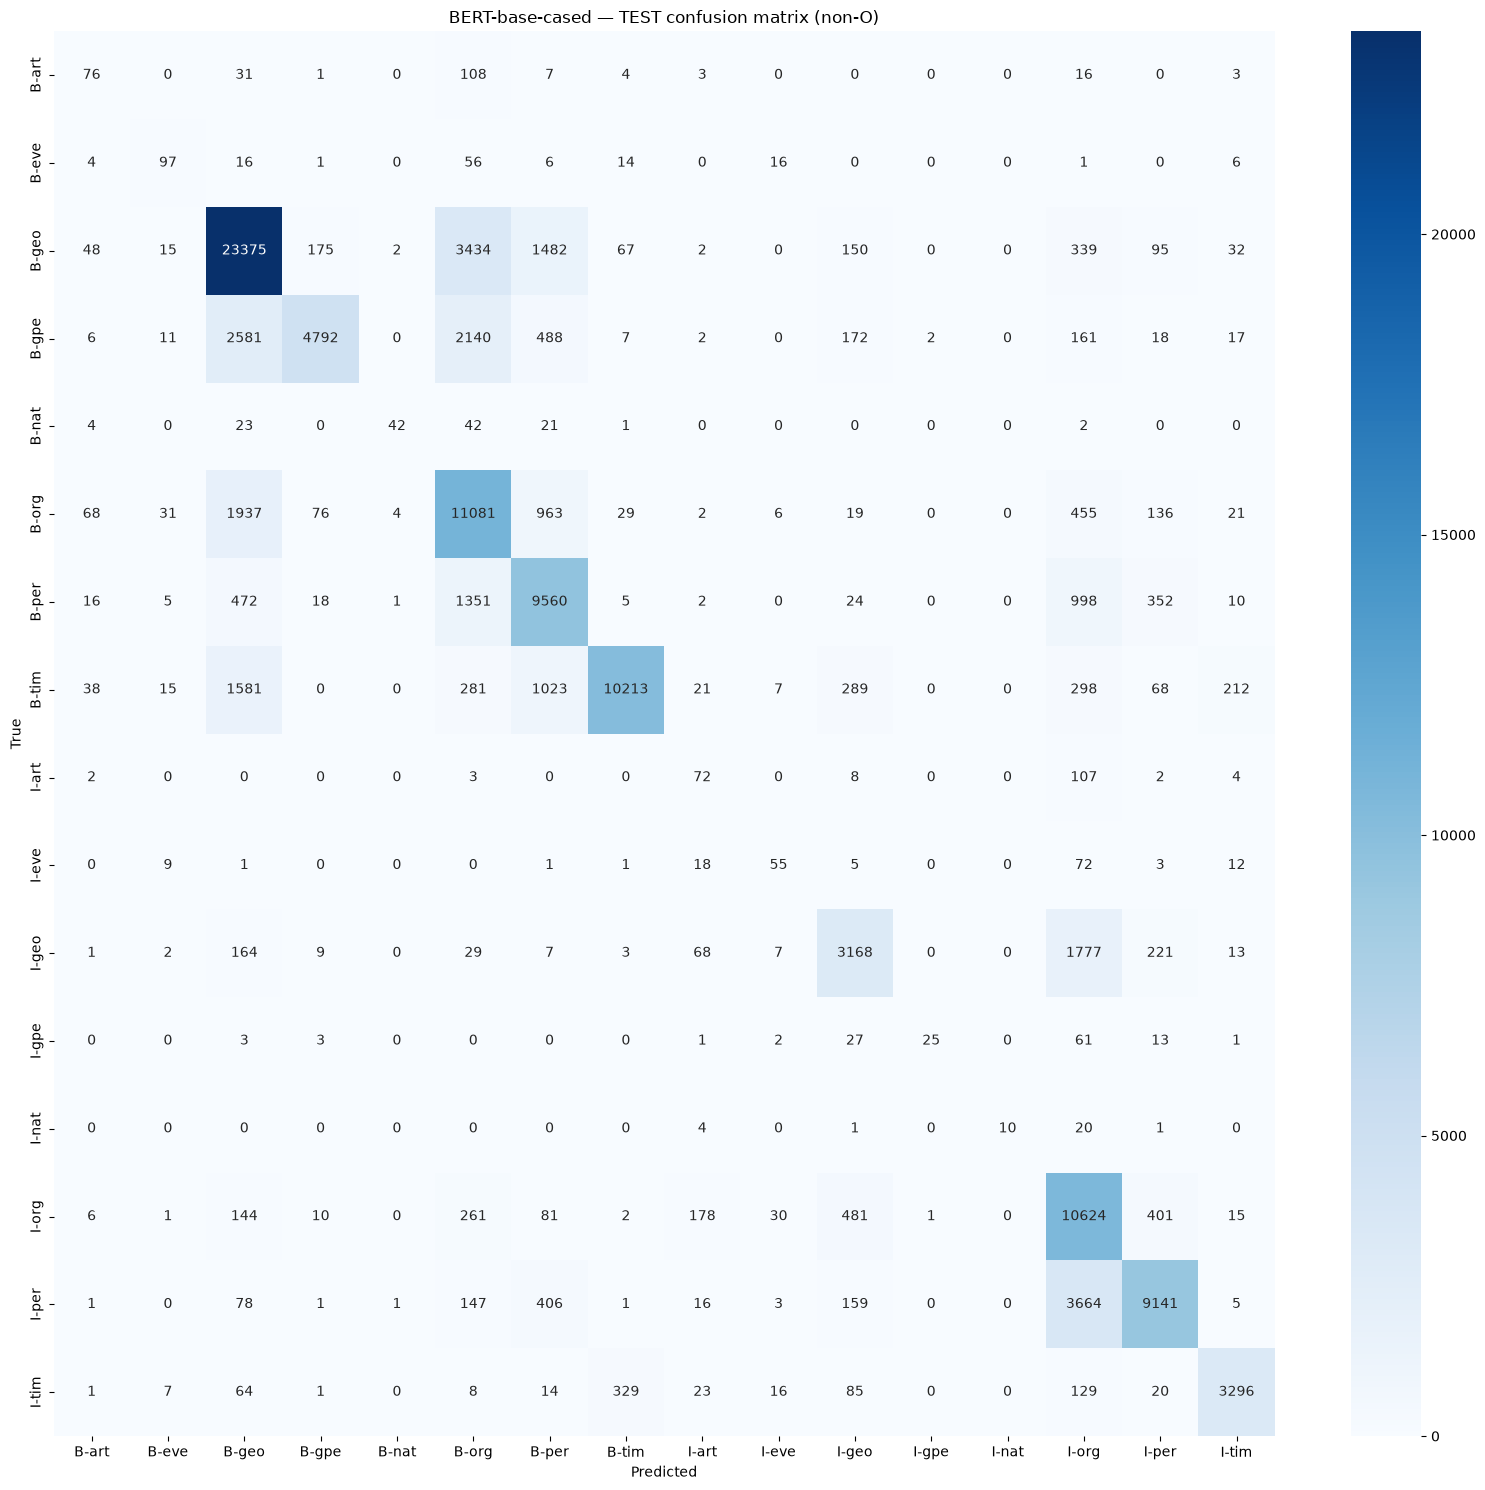

{'accuracy': 0.6677870930005849,
 'f1_macro': 0.5281375117770692,
 'f1_weighted': 0.6945466281950661,
 'report': '              precision    recall  f1-score   support\n\n       B-art     0.2804    0.2397    0.2585       317\n       B-eve     0.5026    0.3992    0.4450       243\n       B-geo     0.7671    0.7762    0.7717     30113\n       B-gpe     0.9420    0.3788    0.5404     12649\n       B-nat     0.8400    0.2400    0.3733       175\n       B-org     0.5850    0.6919    0.6340     16016\n       B-per     0.6800    0.6983    0.6890     13691\n       B-tim     0.9566    0.6331    0.7620     16131\n       I-art     0.1748    0.3258    0.2275       221\n       I-eve     0.3873    0.2792    0.3245       197\n       I-geo     0.6905    0.5337    0.6021      5936\n       I-gpe     0.8929    0.1656    0.2793       151\n       I-nat     1.0000    0.2381    0.3846        42\n       I-org     0.5674    0.8001    0.6640     13278\n       I-per     0.8730    0.6610    0.7523     13830\n    

In [41]:
full_eval("BERT-base-cased", test_labels, y_pred_bert_test, "TEST")


## 7. Model comparison summary

All metrics are computed on **non-O tokens only**, which is the assignment requirement.  
Including O tokens would inflate accuracy to ~95%+ for all models because 85% of tokens are labelled O — a model that predicts everything as O would trivially achieve high accuracy.  

F1 macro averages all 16 non-O class scores equally, penalising poor performance on rare classes (`art`, `eve`, `nat`) as heavily as common ones. F1 weighted averages by class support and better reflects overall practical performance.

In [42]:
rows = []
for name, y_true, y_pred in [
    ("CRF", train_labels, y_pred_crf_train),
    ("CRF", test_labels, y_pred_crf_test),
    ("Struct. Perceptron", train_labels, y_pred_sp_train),
    ("Struct. Perceptron", test_labels, y_pred_sp_test),
    ("BiLSTM-CRF", train_labels, y_pred_bl_train),
    ("BiLSTM-CRF", test_labels, y_pred_bl_test),
    ("BERT-base-cased", train_labels, y_pred_bert_train),
    ("BERT-base-cased", test_labels, y_pred_bert_test),
]:
    split = "Train" if y_true is train_labels else "Test"
    res = evaluate_model(y_true, y_pred, exclude_O=True)
    rows.append(
        {
            "Model": name,
            "Split": split,
            "Acc (non-O)": f"{res['accuracy']:.4f}",
            "F1 Macro": f"{res['f1_macro']:.4f}",
            "F1 Weighted": f"{res['f1_weighted']:.4f}",
        }
    )

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))


             Model Split Acc (non-O) F1 Macro F1 Weighted
               CRF Train      0.6079   0.5208      0.6957
               CRF  Test      0.4152   0.3182      0.5106
Struct. Perceptron Train      0.7914   0.6352      0.8038
Struct. Perceptron  Test      0.6344   0.4179      0.6560
        BiLSTM-CRF Train      0.9562   0.9192      0.9605
        BiLSTM-CRF  Test      0.4884   0.3703      0.5386
   BERT-base-cased Train      0.9515   0.8828      0.9563
   BERT-base-cased  Test      0.6678   0.5281      0.6945


## 8. TINY TEST predictions

The TINY TEST consists of 14 diagnostic sentences designed to probe specific model behaviours:

- Known vs unknown entity spellings (*Paris* vs *Parris*, *Barcelona* vs *Barchelona*)
- Capitalised common nouns that are not entities (*Apple* the fruit vs *Apple* the company)
- Multi-token entities (*New York*, *Saudi Arabia*, *United States of America*)
- Person names with varying capitalisation (*Bill gates* vs *Bill Gates*)

Format: `word/TAG` separated by spaces, one sentence per line.  
Accuracy is computed on non-O ground-truth tokens only, consistent with the main evaluation.

In [43]:
print("=" * 60)
print("TINY TEST — CRF")
print("=" * 60)
print_tiny_test(tiny_sents, y_pred_crf_tiny)

# Accuracy on non-O ground-truth tokens only
_res = evaluate_model(tiny_labels, y_pred_crf_tiny, exclude_O=True)
print(f"\nAccuracy (non-O): {_res['accuracy']:.4f}")


TINY TEST — CRF
The/O programmers/O from/O Barcelona/B-geo might/I-geo write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/I-geo write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-art London/I-art went/I-art to/I-art Parris/I-art ./O
Jack/B-art London/I-art went/I-art to/I-art Paris/I-art ./O
Bill/B-art gates/I-art and/I-art Steve/I-art jobs/I-art never/I-art thought/I-art Microsoft/I-art would/I-art become/I-art such/I-art a/I-art big/I-art company/I-art ./O
Bill/B-art Gates/I-art and/I-art Steve/I-art Jobs/I-art never/I-art thought/I-art Microsoft/I-art would/I-art become/I-art such/I-art a/I-art big/I-art company/I-art ./O
The/O president/O of/O U.S.A/O thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/B-org of/I-org Saudi/I-org Arabia/I-org wanted/O total/O control/O ./O
Robin/B-

In [44]:
print("=" * 60)
print("TINY TEST — Structured Perceptron")
print("=" * 60)
print_tiny_test(tiny_sents, y_pred_sp_tiny)

# Accuracy on non-O ground-truth tokens only
_res = evaluate_model(tiny_labels, y_pred_sp_tiny, exclude_O=True)
print(f"\nAccuracy (non-O): {_res['accuracy']:.4f}")


TINY TEST — Structured Perceptron
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/I-per went/O to/O Parris/B-geo ./O
Jack/B-per London/I-per went/O to/O Paris/B-geo ./O
Bill/B-per gates/I-per and/O Steve/B-per jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-org thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-org States/I-org of/I-org America/I-org thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-org Arabia/I-org wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/O is/O a

In [45]:
print("=" * 60)
print("TINY TEST — BiLSTM-CRF")
print("=" * 60)
print_tiny_test(tiny_sents, y_pred_bl_tiny)

# Accuracy on non-O ground-truth tokens only
_res = evaluate_model(tiny_labels, y_pred_bl_tiny, exclude_O=True)
print(f"\nAccuracy (non-O): {_res['accuracy']:.4f}")


TINY TEST — BiLSTM-CRF
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/I-geo write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/B-geo went/O to/O Parris/O ./O
Jack/B-per London/B-geo went/O to/O Paris/B-geo ./O
Bill/B-per gates/O and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-geo thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/B-per is/O a/O great/O comp

In [46]:
print("=" * 60)
print("TINY TEST — BERT-base-cased")
print("=" * 60)
print_tiny_test(tiny_sents, y_pred_bert_tiny)

# Accuracy on non-O ground-truth tokens only
_res = evaluate_model(tiny_labels, y_pred_bert_tiny, exclude_O=True)
print(f"\nAccuracy (non-O): {_res['accuracy']:.4f}")


TINY TEST — BERT-base-cased
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/I-per went/O to/O Parris/B-geo ./O
Jack/B-per London/I-per went/O to/O Paris/B-geo ./O
Bill/B-per gates/O and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-geo thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/B-org is/O a/O great/O